In [1]:
import tensorflow as tf
from tensorflow.keras import layers as tfl
import numpy as np
import scipy.misc
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet_v2 import preprocess_input, decode_predictions
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity, he_uniform
from tensorflow.python.framework.ops import EagerTensor
from matplotlib.pyplot import imshow
from sklearn.model_selection import train_test_split
import h5py
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras import mixed_precision

# Add this line right at the top of your notebook!
mixed_precision.set_global_policy('mixed_float16')

np.random.seed(1)
tf.random.set_seed(2)

2026-04-28 10:25:17.584995: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 10:25:17.650111: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-28 10:25:17.650175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-28 10:25:17.652668: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-28 10:25:17.664493: I tensorflow/core/platform/cpu_feature_guar

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6


2026-04-28 10:25:21.248895: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.429961: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.430016: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.430431: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
def load_dataset():
    train_dataset=h5py.File("/home/dikshant/projects/ml-fundamentals-pytorch/Dataset/train_signs.h5",'r')
    train_X = np.array(train_dataset["train_set_x"][:])
    train_y = np.array(train_dataset["train_set_y"][:])

    test_dataset = h5py.File("/home/dikshant/projects/ml-fundamentals-pytorch/Dataset/test_signs.h5","r")
    test_X=np.array(test_dataset["test_set_x"][:])
    test_y = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_y = train_y.reshape((1,train_y.shape[0]))
    test_y=test_y.reshape((1,test_y.shape[0]))

    return train_X, train_y, test_X, test_y, classes
    

In [3]:
def IdentityBlock(X,f,filters,initializer=he_uniform):
    #Retrieve filters
    f1,f2,f3=filters

    # Skip connection save this to add into last part
    X_shortcut = X

    # First component of main path # Padding valid
    X = Conv2D(filters =f1, kernel_size = 1, strides =(1,1), padding ='valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis =3)(X) # Default axis
    X = Activation('relu')(X)

    # Second Component of main path # Padding same
    X = Conv2D(filters =f2, kernel_size = f, strides =(1,1), padding ='same', kernel_initializer = initializer(seed =0))(X)
    X = BatchNormalization(axis =3)(X)
    X = Activation('relu')(X)

    # Third component of main path # Padding valid, kernel_size =1
    X = Conv2D(filters = f3, kernel_size = 1, strides =(1,1), padding ='valid', kernel_initializer = initializer(seed =0))(X)
    X = BatchNormalization(axis =3)(X)

    # Final step add shortcut value to the main paths output
    X = Add()([X_shortcut,X])
    X = Activation('relu')(X)

    return X

def ConvolutionBlock(X,f,filters,s=2,initializer = he_uniform):
    #Retrieve filters
    f1,f2,f3 = filters

    # Skip connection save the to add into output of main path
    X_shortcut =X

    # Main path
    # firt component of main path
    X = Conv2D(filters =f1, kernel_size= 1, strides =(s,s), padding ='valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis =3)(X)
    X = Activation('relu')(X)

    # Second component of main path
    X = Conv2D(filters =f2, kernel_size =f, strides =(1,1), padding='same', kernel_initializer= initializer(seed=0))(X)
    X = BatchNormalization(axis =3)(X)
    X= Activation('relu')(X)

    # Third component of main path
    X = Conv2D(filters = f3, kernel_size=1, strides =(1,1), padding ='valid', kernel_initializer= initializer(seed=0))(X)
    X = BatchNormalization(axis=3)(X)

    ## Shortcut path # Adding a convolution layer followed by batch norm to match shortcut dimension with main paths output
    X_shortcut = Conv2D(filters =f3, kernel_size=1, strides =(s,s), padding ='valid', kernel_initializer=initializer(seed=0))(X_shortcut)
    X_shortcut = BatchNormalization(axis=3)(X_shortcut)

    ## Adding shortcut output to main path output
    X = Add()([X,X_shortcut])
    X = Activation('relu')(X)

    return X


In [4]:
def resnet50(input_shape =(64,64,3), classes =6, training =False):
    X_input =Input(input_shape)
  
    #Zero padding
    X = ZeroPadding2D((3,3))(X_input)

    # Stage 1 
    X = Conv2D(filters=64, kernel_size =(7,7), strides=(2,2))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size =(3,3), strides = (2,2))(X)

    # Stage 2 256 channel feature
    X =ConvolutionBlock(X,f=3,filters=[64,64,256],s=1)
    X =IdentityBlock(X,f=3,filters=[64,64,256])
    X = IdentityBlock(X,f=3,filters =[64,64,256])

    # Stage 3 512 Channel feature
    X = ConvolutionBlock(X,f=3,filters=[128,128,512],s=2)
    X = IdentityBlock(X,f=3,filters=[128,128,512])
    X = IdentityBlock(X,f=3,filters=[128,128,512])
    X = IdentityBlock(X,f=3,filters=[128,128,512])


    # Stage 4 1024 Channel feature
    X = ConvolutionBlock(X,f=3,filters=[256,256,1024],s=2)
    X = IdentityBlock(X,f=3,filters=[256,256,1024])
    X = IdentityBlock(X,f=3,filters=[256,256,1024])
    X = IdentityBlock(X,f=3,filters=[256,256,1024])
    X = IdentityBlock(X,f=3,filters=[256,256,1024])
    X = IdentityBlock(X,f=3,filters=[256,256,1024])

    # Stage 5 2048 channel feature
    X = ConvolutionBlock(X,f=3,filters=[512,512,2048])
    X = IdentityBlock(X,f=3,filters=[512,512,2048])
    X = IdentityBlock(X,f=3,filters=[512,512,2048])

    X = GlobalMaxPooling2D()(X)
    X = Flatten()(X)
    X = Dense(classes, activation ='softmax', kernel_initializer = he_uniform(seed=0))(X)

    model = Model(inputs=X_input, outputs=X)
    return model
    
    
    
    

In [5]:
model = resnet50(input_shape = (64, 64, 3), classes = 6)
model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
print(model.summary())

2026-04-28 10:25:21.626986: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.627142: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.627168: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.758659: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 10:25:21.758731: I external/local_xla/xla/stream_executor

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 70, 70, 3)            0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv2d (Conv2D)             (None, 32, 32, 64)           9472      ['zero_padding2d[0][0]']      
                                                                                                  
 batch_normalization (Batch  (None, 32, 32, 64)           256       ['conv2d[0][0]']          

In [6]:
train_X,train_y,test_X,test_y,classes = load_dataset()
train_X.shape, train_y.shape, test_X.shape, test_y.shape, classes.shape

((1080, 64, 64, 3), (1, 1080), (120, 64, 64, 3), (1, 120), (6,))

In [7]:
train_X_norm,test_X_norm = train_X/255.0,test_X/255.0
train_y,test_y=train_y.T,test_y.T

X_train, X_val, y_train, y_val = train_test_split(
    train_X_norm, 
    train_y, 
    test_size=0.20,      # 20% of the data goes to validation
    random_state=42,     # Ensures you get the exact same split every time you run the code
    stratify=train_y     # VERY IMPORTANT: Ensures the ratio of all classes stays the same in all sets
)

In [8]:
print("Number of training examples: ",X_train.shape[0])
print("Number of validation examples: ",X_val.shape[0])
print("Number of test examples: ", test_X_norm.shape[0])
print("train_X_norm shape: ", X_train.shape)
print("Val_X_norm shape: ", X_val.shape)
print("test_X_norm shape: ", test_X_norm.shape)
print("Number of Classes: ", classes[0])
print("y_train shape: ", y_train.shape)
print("y_val shape: ", y_val.shape)
print("test_y shape: ", test_y.shape)

Number of training examples:  864
Number of validation examples:  216
Number of test examples:  120
train_X_norm shape:  (864, 64, 64, 3)
Val_X_norm shape:  (216, 64, 64, 3)
test_X_norm shape:  (120, 64, 64, 3)
Number of Classes:  0
y_train shape:  (864, 1)
y_val shape:  (216, 1)
test_y shape:  (120, 1)


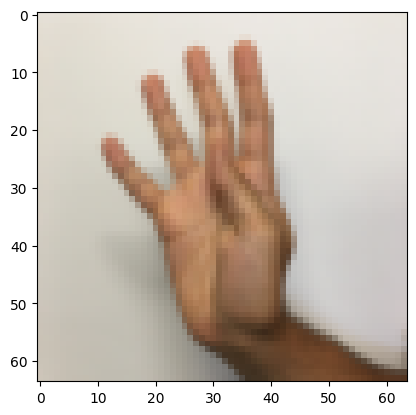

In [9]:
index = 130
plt.imshow(train_X[index]) #display sample training image

plt.show()

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)

history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=8, 
                    validation_data=(X_val, y_val),
                                   callbacks=[early_stop, reduce_lr]
                   )

Epoch 1/100


2026-04-28 10:25:39.777421: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-04-28 10:25:39.789641: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-28 10:25:39.905727: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


  7/108 [>.............................] - ETA: 3s - loss: 6.6535 - accuracy: 0.2143

2026-04-28 10:25:45.248060: I external/local_xla/xla/service/service.cc:168] XLA service 0x7d43ac006ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-28 10:25:45.248109: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-04-28 10:25:45.254769: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777371945.428570   10655 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/108 [==============================] - 32s 107ms/step - loss: 5.0340 - accuracy: 0.3611 - val_loss: 3.1350 - val_accuracy: 0.1713 - lr: 0.0010
Epoch 2/100
108/108 [==============================] - 8s 73ms/step - loss: 4.2347 - accuracy: 0.4167 - val_loss: 2.9063 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 3/100
108/108 [==============================] - 9s 83ms/step - loss: 3.0241 - accuracy: 0.4919 - val_loss: 144.7639 - val_accuracy: 0.1713 - lr: 0.0010
Epoch 4/100
108/108 [==============================] - 9s 80ms/step - loss: 2.0472 - accuracy: 0.6238 - val_loss: 1.0648 - val_accuracy: 0.5972 - lr: 0.0010
Epoch 5/100
108/108 [==============================] - 9s 85ms/step - loss: 2.3233 - accuracy: 0.6331 - val_loss: 134.0208 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 6/100
108/108 [==============================] - 8s 76ms/step - loss: 1.9028 - accuracy: 0.6782 - val_loss: 7.8094 - val_accuracy: 0.6065 - lr: 0.0010
Epoch 7/100
108/108 [==============================] - 9s 83ms/s

In [11]:
model.evaluate(test_X_norm,test_y)


4/4 [==============================] - 5s 857ms/step - loss: 0.2068 - accuracy: 0.9250


[0.20677083730697632, 0.925000011920929]

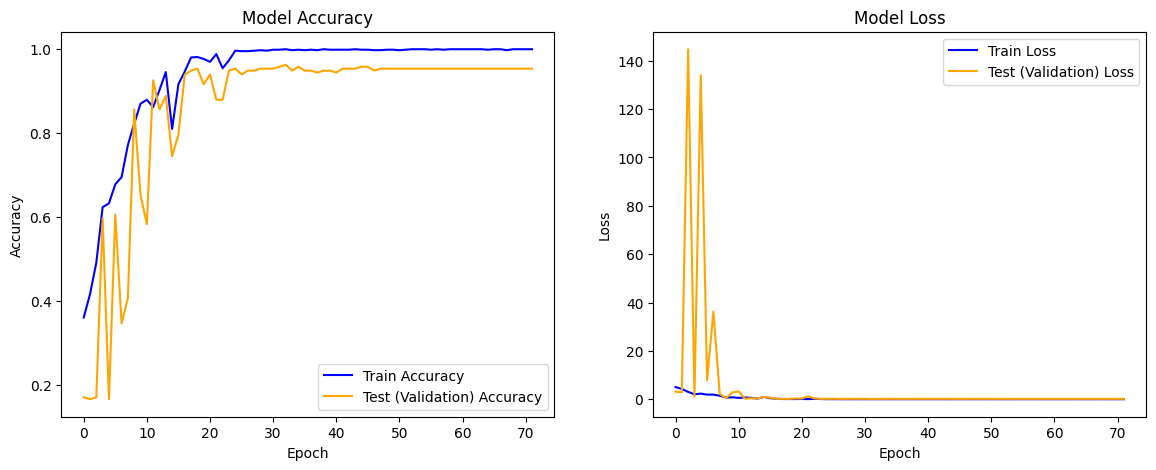

In [12]:
# 2. Plot the loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Test (Validation) Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Test (Validation) Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()